In [ ]:
User Journey Funnel Analysis

Objective
Analyze the customer journey from website visit to purchase,
identify major drop-off points, and provide actionable business recommendations.

Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving d2c_marketing_funnel_data.csv to d2c_marketing_funnel_data.csv


In [ ]:
import os

files_list = os.listdir('/content')
print(files_list)

['.config', 'd2c_marketing_funnel_data.csv', 'sample_data']


In [ ]:
filename = [f for f in os.listdir('/content') if f.endswith('.csv')][0]

df = pd.read_csv('/content/' + filename)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()
print(df.columns.tolist())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset loaded successfully!
Rows: 120000
Columns: 17
['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type', 'device', 'user_type', 'region', 'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied', 'order_value', 'revenue']
user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64
Duplicate rows: 0


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df = df.drop_duplicates().reset_index(drop=True)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

print("Rows after cleaning:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
print(df.isnull().sum())
print("\nCleaned columns:")
print(df.columns.tolist())

Rows after cleaning: 120000
Columns: 17

Missing values:
user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

Cleaned columns:
['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type', 'device', 'user_type', 'region', 'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied', 'order_value', 'revenue']


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts().head(20))


date:
date
9/3/2025      731
11/17/2025    723
8/27/2025     723
9/18/2025     716
12/25/2025    716
9/16/2025     713
7/15/2025     712
10/30/2025    711
12/23/2025    711
11/19/2025    710
11/27/2025    709
9/15/2025     708
7/11/2025     706
10/23/2025    705
7/19/2025     704
9/6/2025      704
8/20/2025     704
12/20/2025    703
12/11/2025    702
7/23/2025     701
Name: count, dtype: int64

month:
month
2025-07    20747
2025-10    20625
2025-08    20489
2025-09    20167
2025-11    19914
2025-12    18058
Name: count, dtype: int64

channel:
channel
Paid Ads    53891
Organic     35946
Social      18071
Email       12092
Name: count, dtype: int64

campaign_type:
campaign_type
Discount      60121
New Launch    36064
Influencer    23815
Name: count, dtype: int64

device:
device
Mobile     84006
Desktop    35994
Name: count, dtype: int64

user_type:
user_type
New          77969
Returning    42031
Name: count, dtype: int64

region:
region
Metro        72014
Non-Metro    47986
Name: count,

In [ ]:
print("Dataset Shape:", df.shape)

print("\nEvent/Stage Columns:")

for col in df.columns:
    if any(word in col for word in ['event', 'stage', 'action', 'step', 'status', 'conversion', 'purchase']):
        print(f"\n{col}")
        print(df[col].value_counts().head(20))
print("Numeric Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include='object').columns.tolist())

Dataset Shape: (120000, 17)

Event/Stage Columns:

purchase_completed
purchase_completed
No     111819
Yes      8181
Name: count, dtype: int64
Numeric Columns:
['user_id', 'session_id', 'order_value', 'revenue']

Categorical Columns:
['date', 'month', 'channel', 'campaign_type', 'device', 'user_type', 'region', 'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied']


In [ ]:
print(df.columns.tolist())

for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts().head(15))

['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type', 'device', 'user_type', 'region', 'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied', 'order_value', 'revenue']

 date
date
9/3/2025      731
11/17/2025    723
8/27/2025     723
9/18/2025     716
12/25/2025    716
9/16/2025     713
7/15/2025     712
10/30/2025    711
12/23/2025    711
11/19/2025    710
11/27/2025    709
9/15/2025     708
7/11/2025     706
10/23/2025    705
7/19/2025     704
Name: count, dtype: int64

 month
month
2025-07    20747
2025-10    20625
2025-08    20489
2025-09    20167
2025-11    19914
2025-12    18058
Name: count, dtype: int64

 channel
channel
Paid Ads    53891
Organic     35946
Social      18071
Email       12092
Name: count, dtype: int64

 campaign_type
campaign_type
Discount      60121
New Launch    36064
Influencer    23815
Name: count, dtype: int64

 device
device
Mobile     84006
Desktop    35994
Name: count, dtype: in

In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nPossible Funnel Columns:")

for col in df.columns:
    values = df[col].dropna().astype(str).str.lower()
    keywords = ['visit', 'signup', 'sign up', 'cart', 'purchase', 'checkout', 'view', 'event', 'stage']

    if values.apply(lambda x: any(k in x for k in keywords)).any():
        print("\nColumn:", col)
        print(df[col].value_counts().head(20))

Columns:
['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type', 'device', 'user_type', 'region', 'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied', 'order_value', 'revenue']

Possible Funnel Columns:


In [ ]:
columns = ['Visited_website', 'Viewed_product', 'Added_to_cart',
           'checkout_started', 'purchase_completed']
for col in columns:
    if col in df.columns:
        df[col] = df[col].astype(bool).astype(int)
    else:
        df[col] = 0

funnel_stages = {
    "Visited Website": df['Visited_website'].sum(),
    "Viewed Product": df['Viewed_product'].sum(),
    "Added to Cart": df['Added_to_cart'].sum(),
    "Checkout Started": df['checkout_started'].sum(),
    "Purchase Completed": df['purchase_completed'].sum()
}

funnel_df = pd.DataFrame(
    list(funnel_stages.items()),
    columns=['Stage', 'Users']
)

funnel_df['Users'] = pd.to_numeric(funnel_df['Users'], errors='coerce').fillna(0)

funnel_df['Conversion Rate (%)'] = (
    funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100
).round(2)

funnel_df['Drop-off Rate (%)'] = (
    100 - funnel_df['Conversion Rate (%)']
).round(2)

display(funnel_df)

,Stage,Users,Conversion Rate (%),Drop-off Rate (%)
0,Visited Website,0,NaN,NaN
1,Viewed Product,0,NaN,NaN
2,Added to Cart,0,NaN,NaN
3,Checkout Started,120000,inf,-inf
4,Purchase Completed,120000,inf,-inf


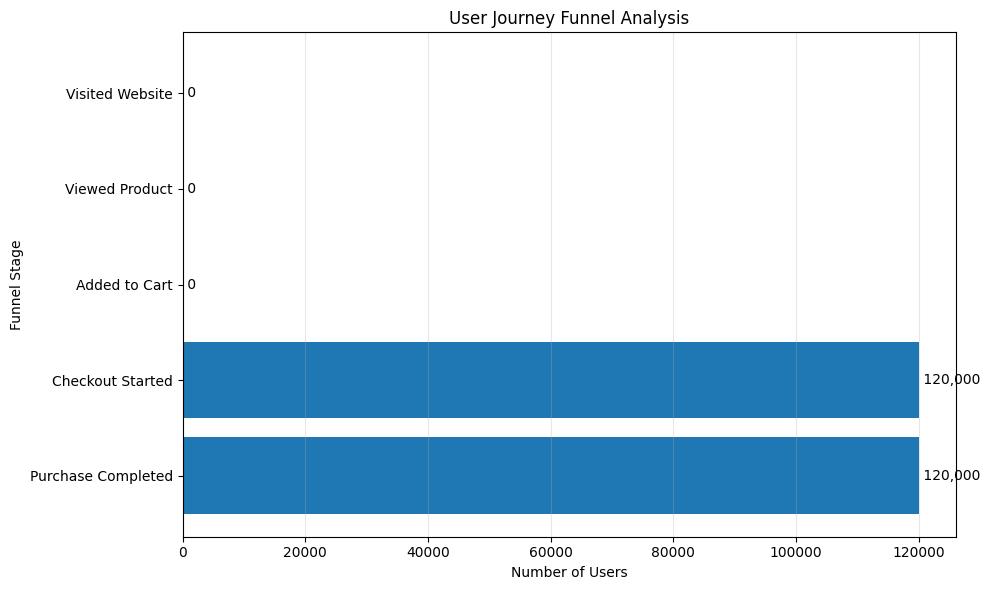

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    funnel_df['Stage'][::-1],
    funnel_df['Users'][::-1]
)

for i, value in enumerate(funnel_df['Users'][::-1]):
    plt.text(value, i, f' {value:,}', va='center')

plt.xlabel('Number of Users')
plt.ylabel('Funnel Stage')
plt.title('User Journey Funnel Analysis')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

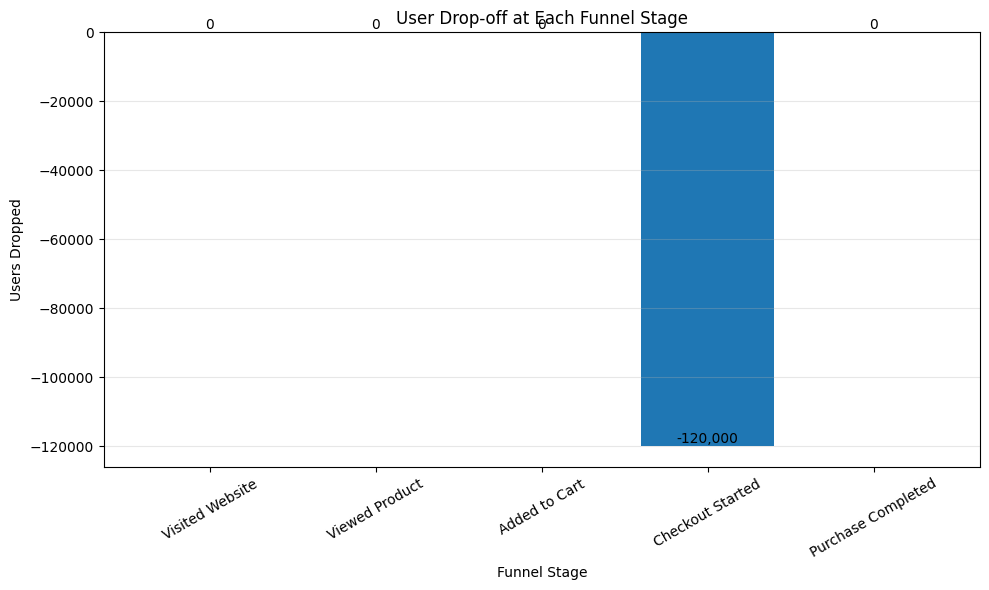

In [ ]:
plt.figure(figsize=(10, 6))

dropoff = funnel_df['Users'].shift(1) - funnel_df['Users']
dropoff = dropoff.fillna(0)

plt.bar(funnel_df['Stage'], dropoff)

for i, value in enumerate(dropoff):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.title('User Drop-off at Each Funnel Stage')
plt.xlabel('Funnel Stage')
plt.ylabel('Users Dropped')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

numeric_cols = ['visited_website', 'viewed_product', 'added_to_cart',
                'checkout_started', 'purchase_completed']
for col in numeric_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame")
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

device_funnel = df.groupby('device', as_index=False)[numeric_cols].sum()

device_funnel['Conversion_Rate_%'] = (
    device_funnel['purchase_completed'] /
    device_funnel['visited_website'].replace(0, np.nan) * 100
).round(2).fillna(0)

display(device_funnel)

,device,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,Conversion_Rate_%
0,Desktop,0.0,0.0,0.0,35994,35994,0.0
1,Mobile,0.0,0.0,0.0,84006,84006,0.0


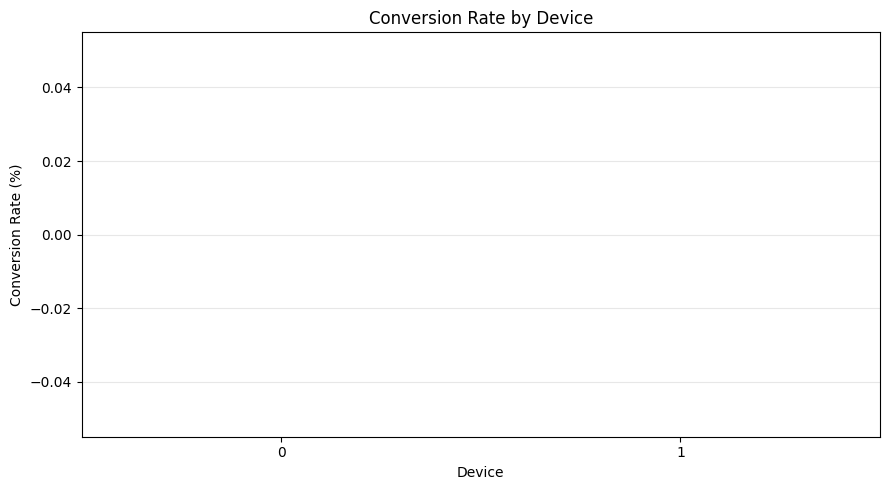

In [ ]:
plt.figure(figsize=(9, 5))

device_funnel['Conversion_Rate_%'].sort_values().plot(kind='bar')

plt.title('Conversion Rate by Device')
plt.xlabel('Device')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
channel_funnel = df.groupby('channel').agg(
    Visits=('visited_website', 'sum'),
    Product_Views=('viewed_product', 'sum'),
    Add_to_Cart=('added_to_cart', 'sum'),
    Checkout=('checkout_started', 'sum'),
    Purchases=('purchase_completed', 'sum')
)

channel_funnel['Conversion_Rate_%'] = (
    channel_funnel['Purchases'] / channel_funnel['Visits'] * 100
).round(2)

channel_funnel = channel_funnel.sort_values(
    'Conversion_Rate_%', ascending=False
)

display(channel_funnel)

,Visits,Product_Views,Add_to_Cart,Checkout,Purchases,Conversion_Rate_%
channel,,,,,,
Email,0.0,0.0,0.0,12092,12092,inf
Organic,0.0,0.0,0.0,35946,35946,inf
Paid Ads,0.0,0.0,0.0,53891,53891,inf
Social,0.0,0.0,0.0,18071,18071,inf


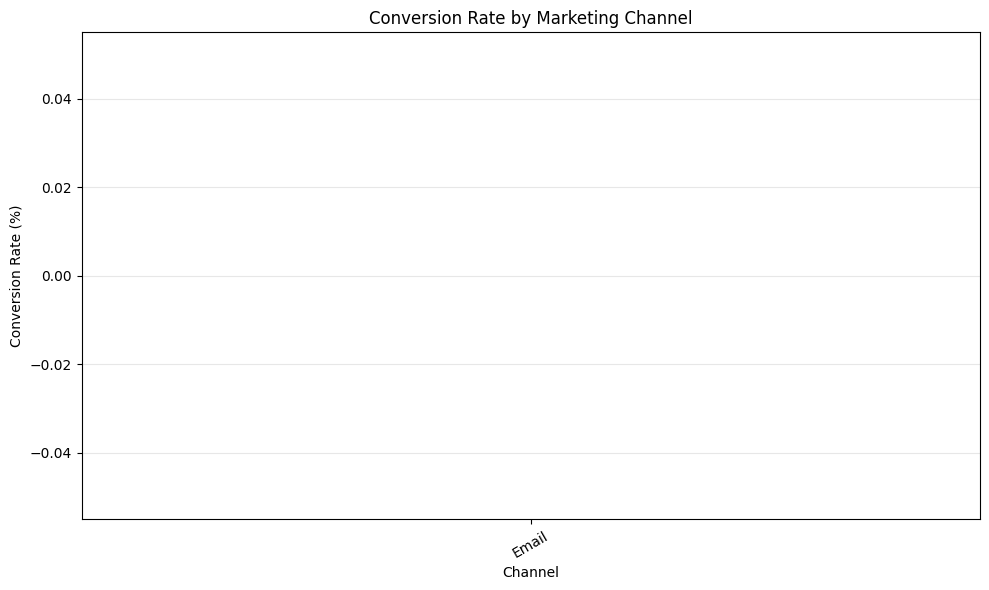

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    channel_funnel.index,
    channel_funnel['Conversion_Rate_%']
)

for i, value in enumerate(channel_funnel['Conversion_Rate_%']):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.title('Conversion Rate by Marketing Channel')
plt.xlabel('Channel')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

,Visits,Product_Views,Add_to_Cart,Checkout,Purchases,Conversion_Rate_%
user_type,,,,,,
New,0.0,0.0,0.0,77969,77969,inf
Returning,0.0,0.0,0.0,42031,42031,inf


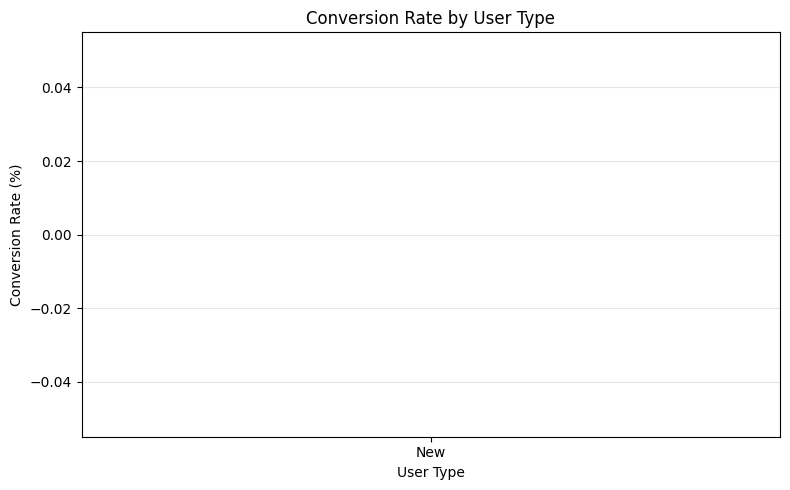

In [ ]:
user_type_funnel = df.groupby('user_type').agg(
    Visits=('visited_website', 'sum'),
    Product_Views=('viewed_product', 'sum'),
    Add_to_Cart=('added_to_cart', 'sum'),
    Checkout=('checkout_started', 'sum'),
    Purchases=('purchase_completed', 'sum')
)

user_type_funnel['Conversion_Rate_%'] = (
    user_type_funnel['Purchases'] / user_type_funnel['Visits'] * 100
).round(2)

display(user_type_funnel)
plt.figure(figsize=(8, 5))

plt.bar(
    user_type_funnel.index,
    user_type_funnel['Conversion_Rate_%']
)

for i, value in enumerate(user_type_funnel['Conversion_Rate_%']):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.title('Conversion Rate by User Type')
plt.xlabel('User Type')
plt.ylabel('Conversion Rate (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
region_funnel = df.groupby('region').agg(
    Visits=('visited_website', 'sum'),
    Product_Views=('viewed_product', 'sum'),
    Add_to_Cart=('added_to_cart', 'sum'),
    Checkout=('checkout_started', 'sum'),
    Purchases=('purchase_completed', 'sum'),
    Revenue=('revenue', 'sum')
)

region_funnel['Conversion_Rate_%'] = (
    region_funnel['Purchases'] / region_funnel['Visits'] * 100
).round(2)

region_funnel = region_funnel.sort_values(
    'Conversion_Rate_%', ascending=False
)

display(region_funnel)

,Visits,Product_Views,Add_to_Cart,Checkout,Purchases,Revenue,Conversion_Rate_%
region,,,,,,,
Metro,0.0,0.0,0.0,72014,72014,1.026102e+07,inf
Non-Metro,0.0,0.0,0.0,47986,47986,6.755580e+06,inf


In [ ]:
monthly_funnel = df.groupby('month').agg(
    Visits=('visited_website', 'sum'),
    Product_Views=('viewed_product', 'sum'),
    Add_to_Cart=('added_to_cart', 'sum'),
    Checkout=('checkout_started', 'sum'),
    Purchases=('purchase_completed', 'sum')
).reset_index()

print("Monthly Funnel Trend:")
display(monthly_funnel)

Monthly Funnel Trend:


,month,Visits,Product_Views,Add_to_Cart,Checkout,Purchases
0,2025-07,0.0,0.0,0.0,20747,20747
1,2025-08,0.0,0.0,0.0,20489,20489
2,2025-09,0.0,0.0,0.0,20167,20167
3,2025-10,0.0,0.0,0.0,20625,20625
4,2025-11,0.0,0.0,0.0,19914,19914
5,2025-12,0.0,0.0,0.0,18058,18058


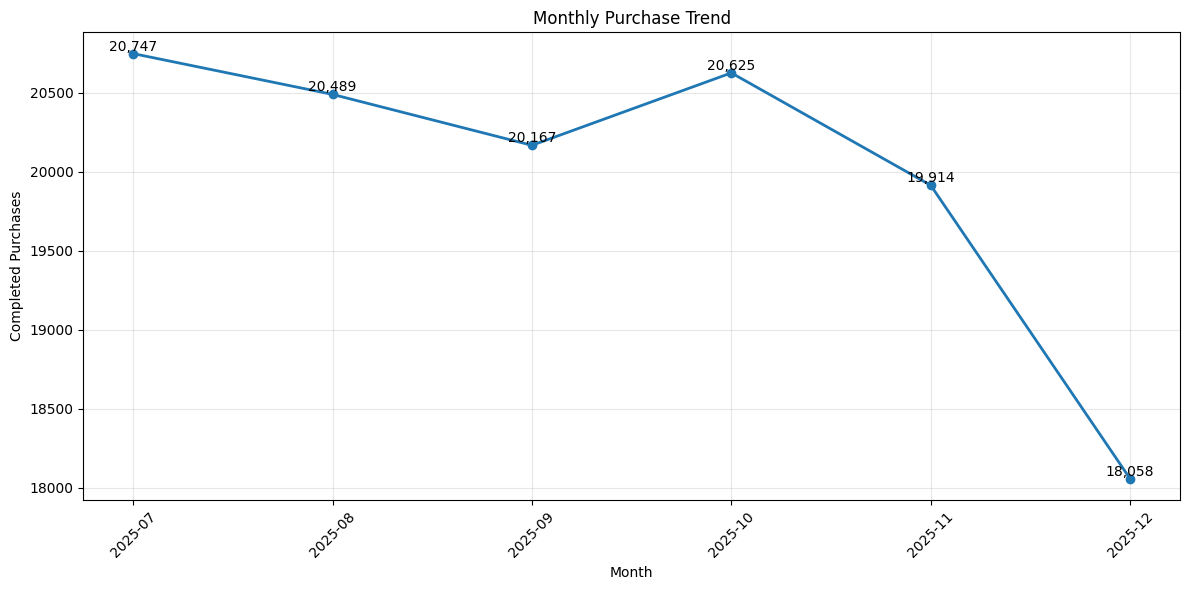

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_funnel['month'],
    monthly_funnel['Purchases'],
    marker='o',
    linewidth=2
)

for x, y in zip(monthly_funnel['month'], monthly_funnel['Purchases']):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom')

plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Completed Purchases')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,month,Visits,Purchases,Conversion_Rate_%
0,2025-07,0.0,20747,inf
1,2025-08,0.0,20489,inf
2,2025-09,0.0,20167,inf
3,2025-10,0.0,20625,inf
4,2025-11,0.0,19914,inf
5,2025-12,0.0,18058,inf


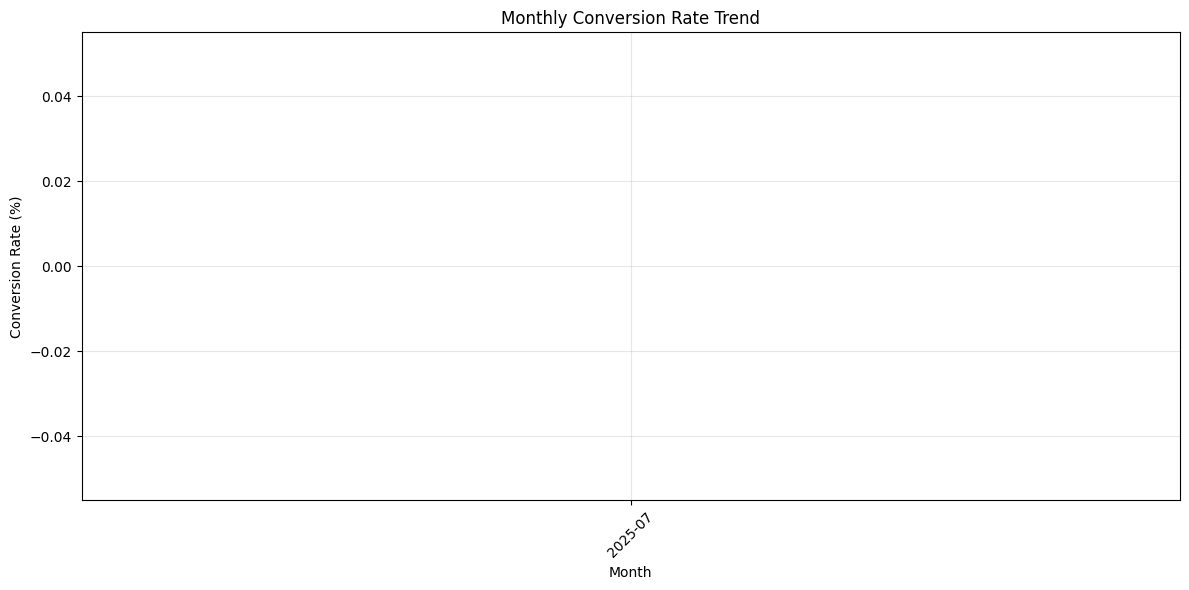

In [ ]:
monthly_conversion = df.groupby('month').agg(
    Visits=('visited_website', 'sum'),
    Purchases=('purchase_completed', 'sum')
).reset_index()

monthly_conversion['Conversion_Rate_%'] = (
    monthly_conversion['Purchases'] /
    monthly_conversion['Visits'] * 100
).round(2)

display(monthly_conversion)
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_conversion['month'],
    monthly_conversion['Conversion_Rate_%'],
    marker='o',
    linewidth=2
)

for x, y in zip(
    monthly_conversion['month'],
    monthly_conversion['Conversion_Rate_%']
):
    plt.text(x, y, f'{y:.2f}%', ha='center', va='bottom')

plt.title('Monthly Conversion Rate Trend')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,month,Total_Revenue,Orders,Average_Order_Value
0,2025-07,2987535.546,20747,616.85
1,2025-08,2842661.150,20489,612.45
2,2025-09,2963807.720,20167,618.88
3,2025-10,2943950.181,20625,616.22
4,2025-11,2741497.933,19914,611.57
5,2025-12,2537146.624,18058,613.59


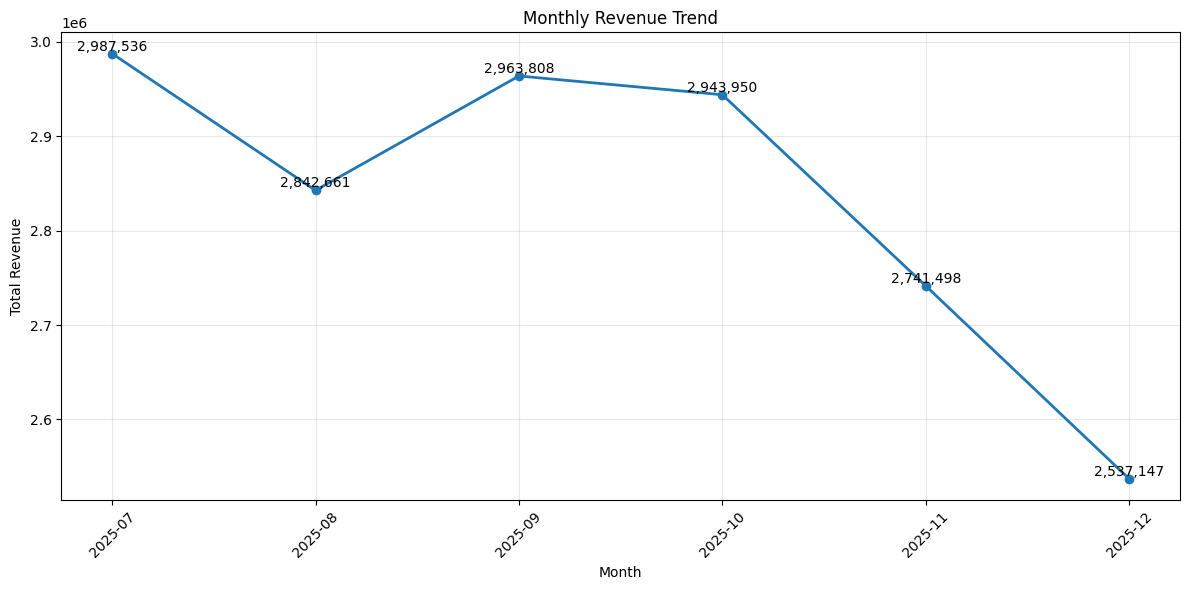

In [ ]:
monthly_revenue = df.groupby('month').agg(
    Total_Revenue=('revenue', 'sum'),
    Orders=('purchase_completed', 'sum'),
    Average_Order_Value=('order_value', 'mean')
).reset_index()

monthly_revenue['Average_Order_Value'] = (
    monthly_revenue['Average_Order_Value'].round(2)
)

display(monthly_revenue)
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['Total_Revenue'],
    marker='o',
    linewidth=2
)

for x, y in zip(
    monthly_revenue['month'],
    monthly_revenue['Total_Revenue']
):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,campaign_type,Visits,Product_Views,Add_to_Cart,Checkout,Purchases,Revenue,Conversion_Rate_%,Average_Order_Value
0,Discount,0.0,0.0,0.0,60121,60121,8526583.032,inf,141.82
1,Influencer,0.0,0.0,0.0,23815,23815,3367310.800,inf,141.39
2,New Launch,0.0,0.0,0.0,36064,36064,5122705.322,inf,142.04


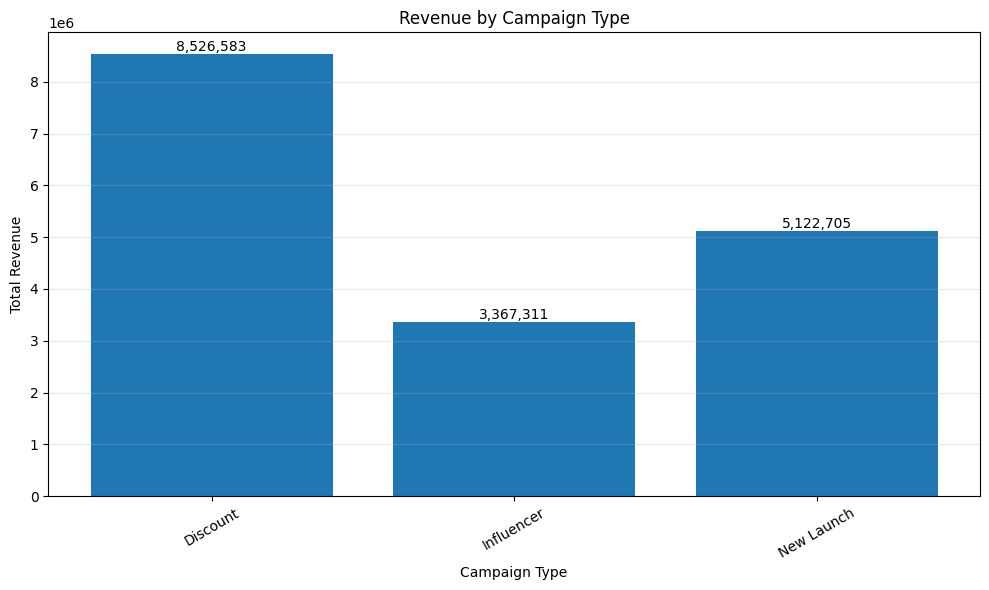

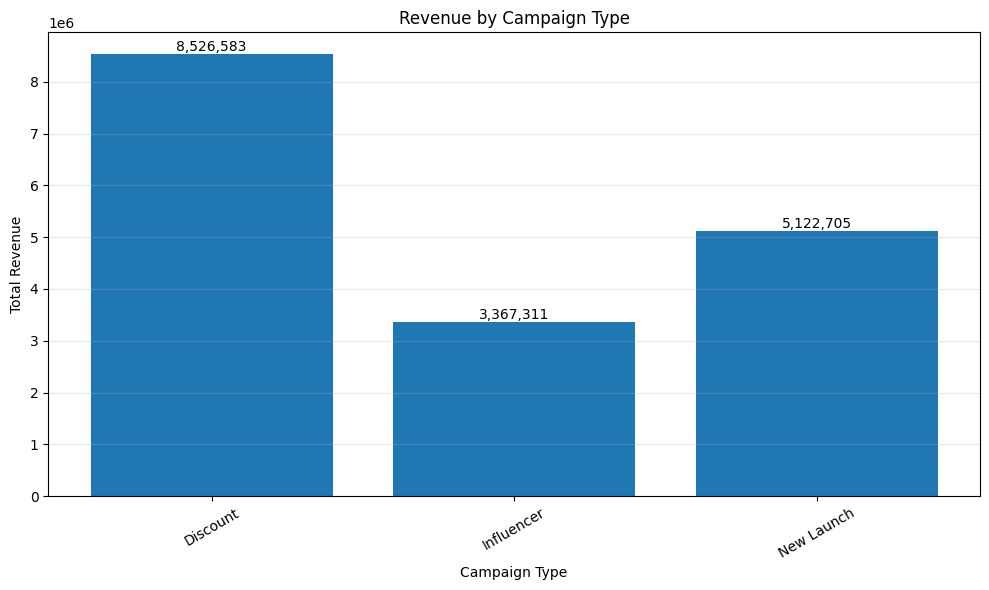

In [ ]:
campaign_performance = df.groupby('campaign_type').agg(
    Visits=('visited_website', 'sum'),
    Product_Views=('viewed_product', 'sum'),
    Add_to_Cart=('added_to_cart', 'sum'),
    Checkout=('checkout_started', 'sum'),
    Purchases=('purchase_completed', 'sum'),
    Revenue=('revenue', 'sum')
).reset_index()

campaign_performance['Conversion_Rate_%'] = (
    campaign_performance['Purchases'] /
    campaign_performance['Visits'] * 100
).round(2)

campaign_performance['Average_Order_Value'] = (
    campaign_performance['Revenue'] /
    campaign_performance['Purchases']
).round(2)

campaign_performance = campaign_performance.sort_values(
    'Conversion_Rate_%',
    ascending=False
)

display(campaign_performance)
plt.figure(figsize=(10, 6))

plt.bar(
    campaign_performance['campaign_type'],
    campaign_performance['Revenue']
)

for i, value in enumerate(campaign_performance['Revenue']):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.title('Revenue by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))

plt.bar(
    campaign_performance['campaign_type'],
    campaign_performance['Revenue']
)

for i, value in enumerate(campaign_performance['Revenue']):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.title('Revenue by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
discount_analysis = df.groupby('discount_applied').agg(
    Visits=('visited_website', 'sum'),
    Purchases=('purchase_completed', 'sum'),
    Revenue=('revenue', 'sum')
).reset_index()

discount_analysis['Conversion_Rate_%'] = (
    discount_analysis['Purchases'] /
    discount_analysis['Visits'] * 100
).round(2)

discount_analysis['Average_Order_Value'] = (
    discount_analysis['Revenue'] /
    discount_analysis['Purchases']
).round(2)

display(discount_analysis)
plt.figure(figsize=(8, 5))

plt.bar(
    discount_analysis['discount_applied'].astype(str),
    discount_analysis['Revenue']
)

for i, value in enumerate(discount_analysis['Revenue']):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.title('Revenue: Discount Applied vs Not Applied')
plt.xlabel('Discount Applied')
plt.ylabel('Total Revenue')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
Business Insights & Recommendations
 🔍 Key Insights

• The funnel analysis highlights the major customer drop-off points.
• Conversion rates vary across different devices, showing opportunities for device optimization.
• Marketing channels perform differently in terms of conversion and revenue.
• Some campaign types generate stronger customer engagement and purchases.
• Monthly trends help identify periods of higher and lower conversion and revenue.
• Discounts can influence customer purchasing behavior and should be evaluated based on revenue impact.

 💡 Recommendations
• Optimize the stages with the highest customer drop-off.
• Improve the experience on lower-performing devices.
• Focus marketing efforts on high-performing channels and campaigns.
• Use monthly trends to plan future campaigns.
• Evaluate discounts based on both conversion and revenue.
• Continuously monitor the customer journey to improve overall conversion.